In [2]:
# %load_ext autoreload
# %autoreload 2@@
import spitap.spec_fit as sf
import lmfit as lm

In [3]:
main_dir = "/home/tbouchet/SPI_SOURCES/obs"
# src_name, spec_dir = 'Crab', '/home/tbouchet/SPI_SOURCES/obs/crab/2023-08-01_2023-10-01_15deg/20_400_35log_SE/fit_0dn_1pi'
# src_name, spec_dir = 'Crab', '/home/tbouchet/SPI_SOURCES/obs/crab/2003-02-19_2003-02-21_15deg/20_600_40log_SE/fit_0dn_1pi'
# src_name, spec_dir = 'SWIFT_J1727.8-1613', f'{main_dir}/S1727/2023-09-07_2023-09-08_15deg/20_400_27perso_SE/fit_0di_1pi'
# src_name, spec_dir= 'GX_354-0', f'{main_dir}/gx339/2021-01-01_2021-04-01_10deg/20_400_20log_SE/fit_0di_1pi'
src_name, spec_dir= 'A0535+32', '/home/tbouchet/SPI_SOURCES/obs/test123/2021-01-01_2021-04-01_10deg/20_400_17perso_SE/fit_0di_1pi'

resp = sf.Response(spec_dir, rmf_ebound_ext='EBOUNDS', rmf_matrix_ext='MATRIX', rmf_name='rmf_spi.rmf')
spec_data= sf.SPISpectrum(src_name, 'SPI')
spec_data.import_spectrum(f'{spec_dir}/spectra_{src_name}.fits', rate_col='DFLUX', rate_err_col='DFLUX_ERR')

Imported response with (N_true x N_detected) = (215x17) channels.
Imported A0535+32 spectrum with 17 channels.


Text(0.5, 1.0, 'Effective RMF')

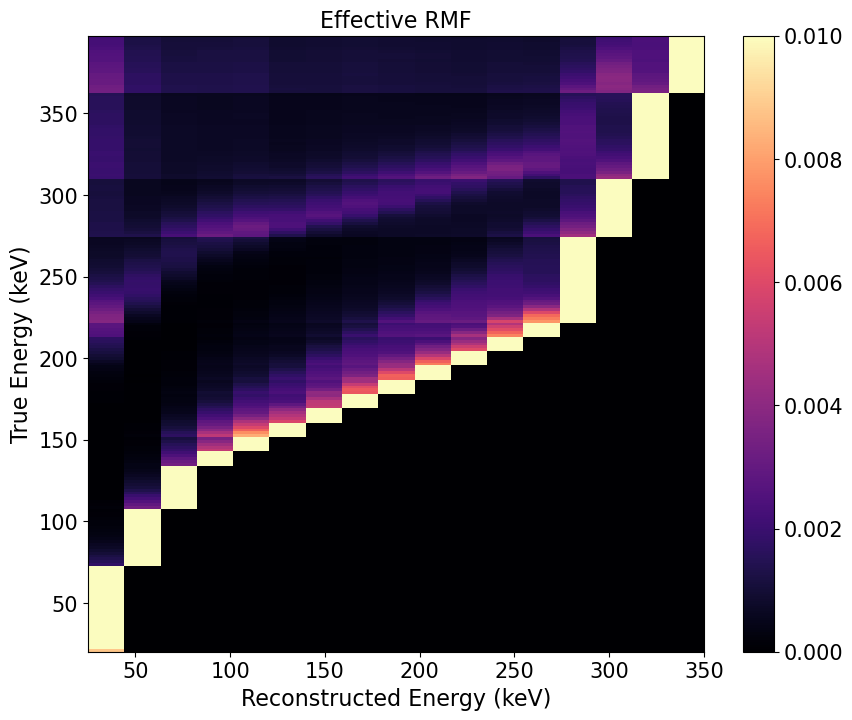

In [4]:
ax, cb=resp.plot_rmf(vmax=.01, effective_rmf=True)
ax.set_title('Effective RMF')

<Axes: xlabel='E (keV)', ylabel='Rate (Counts/s/keV)'>

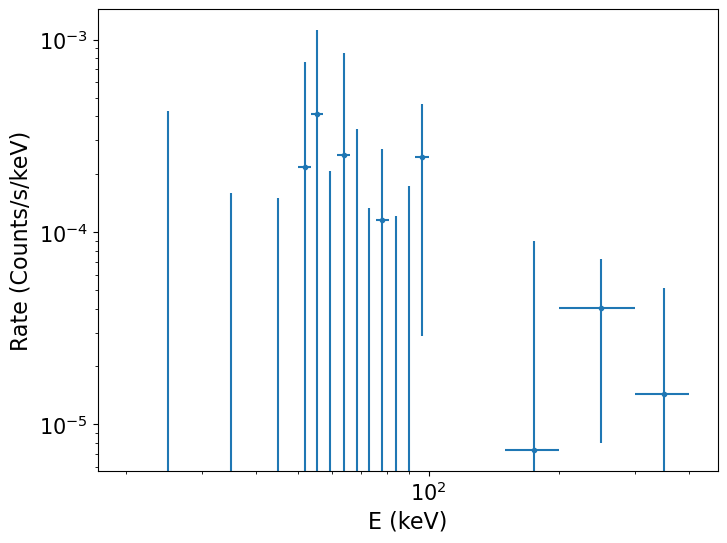

In [5]:
%matplotlib inline
spec_data.import_energy_bands(resp)
spec_data.plot_raw_spec()

In [8]:
e_min_fit, e_max_fit = 50., 400.

lm_params = lm.create_params(
    K = {'value': 10.}, gamma = {'value':2.}, Epiv= {'value':100, 'vary':0}
    # K = {'value': 10.}, gamma = {'value':2.}, Ecut= {'value':100, 'vary':1}
    # K = {'value': 10.}, gamma1 = {'value':2.}, gamma2= {'value':2.3}, Eb={'value':100., 'vary':False} 
    )
# fit = sf.Fit(model_name='cutoffpl')
fit = sf.Fit(model_name='powerlaw')
# fit = sf.Fit(model_name='bknpl')
result, _ =fit.fit_spec(spec_data, resp, lm_params, e_min_fit, e_max_fit)
result

P-value of chi2 = 95.73 %
fit_spec took 0.018s


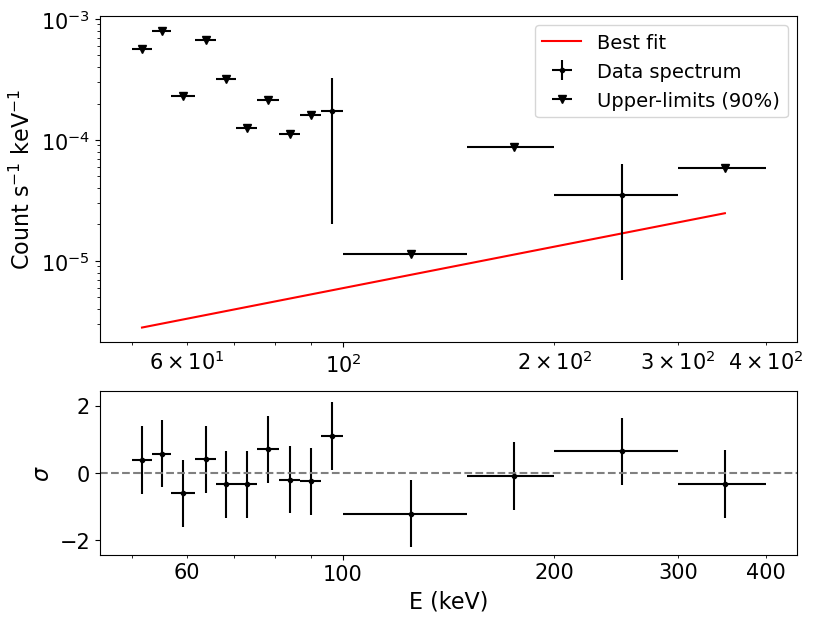

In [9]:
axes=fit.plot_fit(e_min_fit=e_min_fit, e_max_fit=e_max_fit, spec_type='RATE', res_type='RES', uplim_proba=.9)

from matplotlib.ticker import LogFormatter
formatter = LogFormatter(labelOnlyBase=False, minor_thresholds=(3, 0.4))
axes[1,0].xaxis.set_major_formatter(formatter)
axes[1,0].xaxis.set_minor_formatter(formatter)
# axes[0,0].grid(which='both')
# axes[1,0].grid()

# test

In [27]:
import numpy as np
# sum_rmf = resp.dJ * resp.arf@resp.rmf_mat# / resp.dI
rmf_eff = resp.dJ[:, np.newaxis] * resp.arf[:, np.newaxis] * resp.rmf_mat / resp.dI[np.newaxis, :]
rmf_eff

array([[0.02384186, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.07170647, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.09729067, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00371877, 0.00274918, 0.00196144, ..., 0.00220478, 0.00260938,
        0.10477224],
       [0.00365562, 0.00270263, 0.00193393, ..., 0.00226199, 0.00251781,
        0.10506038],
       [0.00360921, 0.00268133, 0.00190363, ..., 0.00237881, 0.00244985,
        0.10528324]], shape=(200, 20))

In [28]:
rmf_eff = resp.dJ[:, np.newaxis] * resp.arf[:, np.newaxis] * resp.rmf_mat / resp.dI[np.newaxis, :]

model_flux = fit.model.calc(resp.J, fit.model_parameters) # flux (ph/cm2/s/keV) is always calculated using the RMF energies (J)
rate1=((model_flux * resp.dJ * resp.arf)@resp.rmf_mat / resp.dI) # conversion flux->count/s with instrument response (RMF+ARF) and energy bin size (rmf_dI, rmf_dJ)
rate2= model_flux @ rmf_eff
rate1, rate2

(array([1.23745769e-03, 1.10276769e-03, 8.55220615e-04, 6.42810479e-04,
        4.68347557e-04, 3.30513647e-04, 2.25357832e-04, 1.48434900e-04,
        9.24949264e-05, 5.50735304e-05, 3.09908354e-05, 1.60241030e-05,
        7.66601581e-06, 3.36467075e-06, 1.32383619e-06, 4.58584334e-07,
        1.38636237e-07, 3.55812580e-08, 7.52554619e-09, 1.25857122e-09]),
 array([1.23745769e-03, 1.10276769e-03, 8.55220615e-04, 6.42810479e-04,
        4.68347557e-04, 3.30513647e-04, 2.25357832e-04, 1.48434900e-04,
        9.24949264e-05, 5.50735304e-05, 3.09908354e-05, 1.60241030e-05,
        7.66601581e-06, 3.36467075e-06, 1.32383619e-06, 4.58584334e-07,
        1.38636237e-07, 3.55812580e-08, 7.52554619e-09, 1.25857122e-09]))